In [1]:
# Install Libraries
!pip install tensorflow
!pip install opencv-python
!pip install matplotlib
!pip install scikit-learn
!pip install pillow
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 106.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 97.8 MB/s eta 0:00:00


# Import Libraries


In [2]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D

from tensorflow.keras.layers import MaxPooling2D

from tensorflow.keras.layers import Flatten

from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

import matplotlib.pyplot as plt

import numpy as np

# Data Preprocessing

In [3]:
# Image Augmentation
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.2

)


# Mount the Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Define Paths

In [5]:
train_path = "/content/drive/MyDrive/Brain_Tumor/Training"
test_path = "/content/drive/MyDrive/Brain_Tumor/Testing"

# Create ImageDataGenerator

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
!ls "/content/drive/MyDrive"

 app.py
 archive.zip
'Brain tumor classification.zip'
 brain_tumor_cnn.keras
'Brain tumor MRI dataset.zip'
 BrainTumorProject
 Classroom
'Colab Notebooks'
'Copy of brain_tumor_cnn.keras'
'Copy of Copy of brain_tumor_cnn.keras'
'IC assignment.pdf'
 IMG_20230624_114704~2.jpg
 IMG_20250810_174446.jpg
'PDF Scanner 02-10-23 10.37.02.pdf'
 requirement.txt
'resume11 (1).pdf'
'resume11 (1).PDF'
 resume11.pdf
 resumeDA.pdf
 Screenshot_20260519_134646_PhonePe.jpg


In [10]:
!unzip "/content/drive/MyDrive/archive.zip" -d "/content/dataset"

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/Training/glioma/Tr-gl_279.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_28.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_280.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_281.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_282.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_283.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_284.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_285.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_286.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_287.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_288.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_289.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_29.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_290.jpg  
  inflating: /content/dataset/Training/glioma/Tr-gl_291.jpg  
  inflating: /content

In [11]:
!ls "/content/dataset"

Testing  Training


In [12]:
train_path = "/content/dataset/Training"
test_path = "/content/dataset/Testing"

# Training Generator

In [13]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

Found 4480 images belonging to 4 classes.


# Validation Generator

In [14]:
validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 1120 images belonging to 4 classes.


# Test Generator(used after training)

In [15]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 1600 images belonging to 4 classes.


In [19]:
import os

print(os.listdir("/content/dataset"))
print(os.listdir("/content/dataset/Training"))
print(os.listdir("/content/dataset/Testing"))

['Testing', 'Training']
['glioma', 'pituitary', 'meningioma', 'notumor']
['glioma', 'pituitary', 'meningioma', 'notumor']


# Load Dataset

In [20]:
train_generator = train_datagen.flow_from_directory(

    train_path,

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    subset="training"

)

Found 4480 images belonging to 4 classes.


In [21]:
validation_generator = train_datagen.flow_from_directory(

    test_path,

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    subset="validation"

)

Found 320 images belonging to 4 classes.


# Check Classes

In [22]:
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


# CNN Model

In [23]:
# Build CNN
model = Sequential()

model.add(Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), activation="relu"))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, (3,3), activation="relu"))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128,activation="relu"))

model.add(Dropout(0.5))

model.add(Dense(4,activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Model Summary

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

# Model Compilation

In [25]:
# Compile
model.compile(

optimizer="adam",

loss="categorical_crossentropy",

metrics=["accuracy"]

)

# Model Training

In [27]:
# Train
history = model.fit(

train_generator,

epochs=5,

validation_data=validation_generator

)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 553s 4s/step - accuracy: 0.5824 - loss: 0.9512 - val_accuracy: 0.6250 - val_loss: 0.9699
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 567s 4s/step - accuracy: 0.7194 - loss: 0.7106 - val_accuracy: 0.6094 - val_loss: 1.1405
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 564s 4s/step - accuracy: 0.7500 - loss: 0.6407 - val_accuracy: 0.6781 - val_loss: 0.8537
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 560s 4s/step - accuracy: 0.7583 - loss: 0.5986 - val_accuracy: 0.6687 - val_loss: 0.8716
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 557s 4s/step - accuracy: 0.7808 - loss: 0.5629 - val_accuracy: 0.6562 - val_loss: 0.8683


# Performance

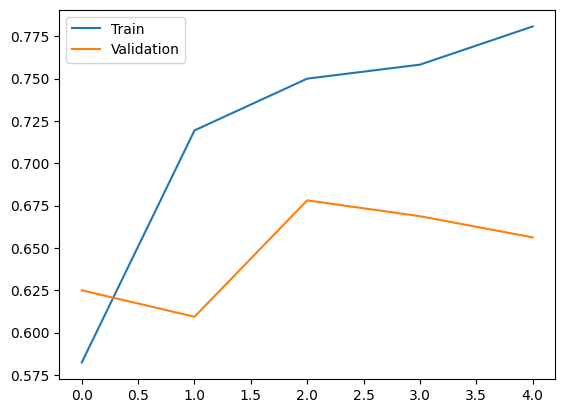

In [28]:
# Plot Accuracy
plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.legend(["Train","Validation"])

plt.show()

# Plot Loss

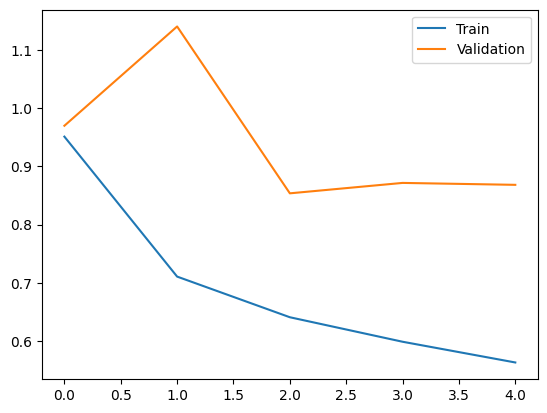

In [29]:
plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Train","Validation"])

plt.show()

# Evaluate

In [30]:
loss,accuracy=model.evaluate(validation_generator)

print(accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6719 - loss: 0.8554
0.671875


# Save Model

In [31]:
model.save("brain_tumor_model.keras")

# Prediction

In [32]:
# Load Model
from tensorflow.keras.models import load_model

model=load_model("brain_tumor_model.keras")

In [36]:
import os

for root, dirs, files in os.walk("/content/dataset/Training"):
    print(root)
    print(files[:5])   # Shows the first 5 files
    break

/content/dataset/Training
[]


In [38]:
!find /content/dataset -maxdepth 3 -type d

/content/dataset
/content/dataset/Testing
/content/dataset/Testing/glioma
/content/dataset/Testing/pituitary
/content/dataset/Testing/meningioma
/content/dataset/Testing/notumor
/content/dataset/Training
/content/dataset/Training/glioma
/content/dataset/Training/pituitary
/content/dataset/Training/meningioma
/content/dataset/Training/notumor


In [39]:
!find /content/dataset -maxdepth 3 -type f | head -20

/content/dataset/Testing/glioma/Te-gl_106.jpg
/content/dataset/Testing/glioma/Te-gl_385.jpg
/content/dataset/Testing/glioma/Te-gl_7.jpg
/content/dataset/Testing/glioma/Te-gl_386.jpg
/content/dataset/Testing/glioma/Te-gl_290.jpg
/content/dataset/Testing/glioma/Te-gl_24.jpg
/content/dataset/Testing/glioma/Te-gl_277.jpg
/content/dataset/Testing/glioma/Te-gl_238.jpg
/content/dataset/Testing/glioma/Te-gl_244.jpg
/content/dataset/Testing/glioma/Te-gl_250.jpg
/content/dataset/Testing/glioma/Te-gl_12.jpg
/content/dataset/Testing/glioma/Te-gl_160.jpg
/content/dataset/Testing/glioma/Te-gl_381.jpg
/content/dataset/Testing/glioma/Te-gl_371.jpg
/content/dataset/Testing/glioma/Te-gl_121.jpg
/content/dataset/Testing/glioma/Te-gl_138.jpg
/content/dataset/Testing/glioma/Te-gl_289.jpg
/content/dataset/Testing/glioma/Te-gl_125.jpg
/content/dataset/Testing/glioma/Te-gl_201.jpg
/content/dataset/Testing/glioma/Te-gl_57.jpg


In [43]:
!find "/content/dataset/Training" -type f | head -20

/content/dataset/Training/glioma/Tr-gl_974.jpg
/content/dataset/Training/glioma/Tr-gl_1314.jpg
/content/dataset/Training/glioma/Tr-gl_508.jpg
/content/dataset/Training/glioma/Tr-gl_698.jpg
/content/dataset/Training/glioma/Tr-gl_335.jpg
/content/dataset/Training/glioma/Tr-gl_1020.jpg
/content/dataset/Training/glioma/Tr-gl_883.jpg
/content/dataset/Training/glioma/Tr-gl_929.jpg
/content/dataset/Training/glioma/Tr-gl_110.jpg
/content/dataset/Training/glioma/Tr-gl_1165.jpg
/content/dataset/Training/glioma/Tr-gl_617.jpg
/content/dataset/Training/glioma/Tr-gl_478.jpg
/content/dataset/Training/glioma/Tr-gl_290.jpg
/content/dataset/Training/glioma/Tr-gl_1113.jpg
/content/dataset/Training/glioma/Tr-gl_672.jpg
/content/dataset/Training/glioma/Tr-gl_425.jpg
/content/dataset/Training/glioma/Tr-gl_725.jpg
/content/dataset/Training/glioma/Tr-gl_85.jpg
/content/dataset/Training/glioma/Tr-gl_892.jpg
/content/dataset/Training/glioma/Tr-gl_659.jpg


# Read Image

In [44]:
from tensorflow.keras.preprocessing import image

img = image.load_img(
    "/content/dataset/Training/glioma/Tr-gl_974.jpg",
    target_size=(224, 224)
)

# Prediction

In [46]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    "/content/dataset/Training/glioma/Tr-gl_974.jpg",
    target_size=(224, 224)
)

# Convert to NumPy array
img = image.img_to_array(img)

# Add batch dimension
img = np.expand_dims(img, axis=0)

# Normalize if your model was trained with rescale=1./255
img = img / 255.0

prediction = model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


In [47]:
classes = ["Glioma", "Meningioma", "Notumor", "Pituitary"]

pred = np.argmax(prediction, axis=1)[0]

print("Predicted Class:", classes[pred])
print("Confidence:", prediction[0])

Predicted Class: Glioma
Confidence: [8.0329692e-01 1.7993949e-01 6.7191967e-04 1.6091688e-02]


# Upload MRI

In [48]:
import streamlit as st

uploaded_file = st.file_uploader(

"Upload MRI",

type=["jpg","png","jpeg"]

)

2026-07-26 13:36:33.269 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 13:36:33.270 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 13:36:33.284 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 13:36:33.632 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-26 13:36:33.633 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 13:36:33.634 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


# Display Image

# Predict

In [49]:
if st.button("Predict"):

    prediction=model.predict(img)

    st.success(

    classes[np.argmax(prediction)]

    )

2026-07-26 13:36:44.199 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 13:36:44.203 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 13:36:44.204 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 13:36:44.206 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 13:36:44.208 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


# Confidence

In [50]:
confidence=np.max(prediction)*100

st.write(

f"Confidence : {confidence:.2f}%"

)

2026-07-26 13:36:52.180 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 13:36:52.182 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-26 13:36:52.183 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
